<a href="https://colab.research.google.com/github/sbanty/DL-ML/blob/main/Classification_of_MNIST_dataset_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow                          # Main Google library for deep learning and neural networks
from tensorflow import keras              # Keras is TensorFlow's high-level API that makes neural networks easier to build
from tensorflow.keras import Sequential   # Sequential = Linear stack of layers (Layer 1 → Layer 2 → Layer 3 → ...)
from tensorflow.keras.layers import Dense, Flatten  # Dense = Fully connected layer (every neuron connects to all next neurons), Flatten = Converts 2D image (28x28) to 1D list (784 numbers)

Without imports:
┌─────────────────────────────────────────────────────────┐
│ You would need to write hundreds of lines of code       │
│ to build neural networks from scratch                   │
└─────────────────────────────────────────────────────────┘

With these imports:
┌─────────────────────────────────────────────────────────┐
│ import tensorflow        → Get the engine               |
│ from tensorflow import keras → Get the easy interface   │
│ from tensorflow.keras import Sequential → Build layers  │
│ from tensorflow.keras.layers import Dense, Flatten      │
│                          → Add specific layer types     │
└─────────────────────────────────────────────────────────┘

Result: We can build a neural network in just 5-10 lines!

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()   # Load MNIST dataset (60k train + 10k test images of handwritten digits 0-9)

Data of Images are in the pixel values form

In [ ]:
X_train   # Stores 60,000 handwritten digit images (each 28x28 pixels) for training the model

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

3D Array where we have 60000 images data: per image is 28*28 numpy array

In [ ]:
X_train.shape   # (60000, 28, 28) → 60,000 images, each 28 pixels tall × 28 pixels wide

(60000, 28, 28)

If we taken the 1st Item : Pixel values are arranged in row wise ...

In [ ]:
X_train[0]   # First image (28x28 pixel values) from 60,000 training images, range 0 to 255

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [ ]:
X_train[0].shape   # (28, 28) → First image has 28 rows and 28 columns of pixels

(28, 28)

In Xtest this also a 3d array : have 10000 of images in Xtest

In [ ]:
X_test.shape   # (10000, 28, 28) → 10,000 test images, each 28x28 pixels

(10000, 28, 28)

In y train is  our lebels. That show In that image which digit is there

In [ ]:
y_train   # Array of 60,000 labels (digits 0-9) corresponding to each training image

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

We can convert pixel value to image

Write code for the 1st image

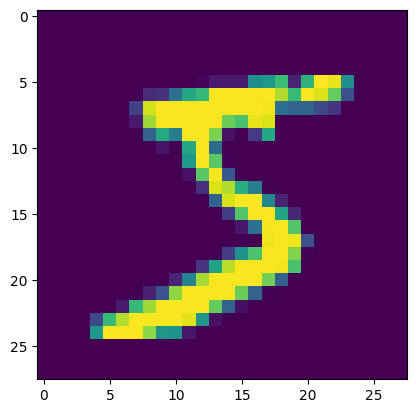

In [ ]:
import matplotlib.pyplot as plt   # Library for displaying images and plotting graphs
plt.imshow(X_train[0])            # Shows first training image (digit 5) as a picture

Write code for the second image

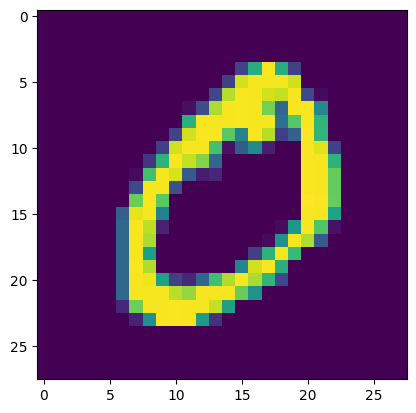

In [ ]:
plt.imshow(X_train[1])   # Shows second training image (digit 0) as a picture

For 3rd image

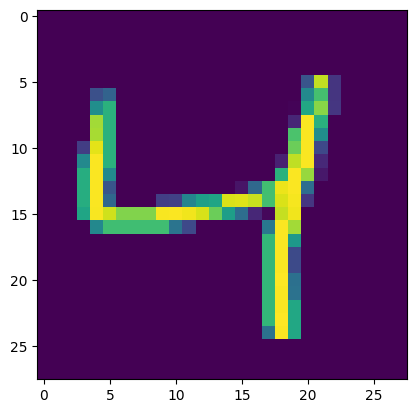

In [ ]:
plt.imshow(X_train[2])   # Shows third training image (digit 4) as a picture

Now we make a NN Architecture where we pass the data, there data will train and understand : when and which pixel value gives which digits

1st arrange these arrays o to 1 of all values. Why? : When you will train the NN If the values be in similar range then we get weights accurately and quickly, and also convergence will fast.

In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

All values are devided by the maximum value 255 : If we devide with itself on max value the value will be 1 , If we devide with minimum value (0) the value will be 0-----> So all pixel values are in that case all values are arranged in 0 and 1 form

In [ ]:
X_train = X_train/255   # Normalize training images: convert pixel values from 0-255 to 0-1 range
X_test = X_test/255     # Normalize test images: convert pixel values from 0-255 to 0-1 range

In [ ]:
X_train [0]  #is the 1st photograph so here we see all values arranged in between 0 to 1

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Now start making ANN, before that we will start with that model is sequential here we need to add the layers

We need to give value in 1st layer is 784 but one problem is there out data is on 28*28 form;

Step 1:Flatten the 28*28 layer

In image all pixel values are arranged in 2D (like they are arranged like in 1st row, 2nd row, 3rd row up to down form)

Step 2 : Arrange these rows value in side by side (from 1 to 28 that means 0 to 27)

Step 3: TO solving this we use the Flatted layer concept with in the keras (Who convert Higher dimensional array to 1D)

In [ ]:
model = tensorflow.keras.Sequential()   # Creates empty model to add layers one by one

model.add(Flatten(input_shape=(28,28)))   # Converts 28x28 image (784 pixels) into 1D array of 784 inputs

model.add(Dense(128, activation='relu'))  # Hidden layer 1: 128 neurons, ReLU activation (finds patterns from 784 inputs)

model.add(Dense(32, activation='relu'))   # Hidden layer 2: 32 neurons, extra layer to learn more complex patterns

model.add(Dense(10, activation='softmax')) # Output layer: 10 neurons (digits 0-9), softmax gives probabilities that sum to 1

# model.add(Flatten(input_shape=(28,28))) - ------- # In Flatten input shape is 28*28 it converts data to 1d means 784 inputs
# model.add(Dense(128, activation='relu')) ------ #Here In dense layer and here 128 inputs or nodes we given...................Flatten gives O/p to dense
# model.add(Dense(32, activation ='relu')) ------#Here I add extra hidden layer 32 nodes
# model.add(Dense(10, activation='softmax')) -----# We have to our o/p layer have 10 nodes because we have 10 output functions, here activation taken as softmax classification : because we have more than one output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()   # Shows model architecture: layers, output shapes, and total trainable parameters (weights + biases)
 # Displays layer-by-layer information about your neural network

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

1. Flatten:
            Output (None, 784) : None = batch size (flexible), 784 = 28×28 pixels flattened

Parameters = 0 : Flatten just reshapes, no learning happens here

2. Dense (128):

        Formula: Parameters = (Input_neurons × Output_neurons) + Output_neurons

= (784 × 128) + 128
= 100,352 + 128
= 100,480

Where:
- 784 × 128 = weights (connections from 784 inputs to 128 neurons)
- +128 = biases (one bias per neuron)

3. Dense(32):

       Formula: (Previous_neurons × Current_neurons) + Current_neurons

= (128 × 32) + 32
= 4,096 + 32
= 4,128

Where:
- 128 = neurons from previous layer
- 32 = neurons in current layer

4. Dense(10):

        = (32 × 10) + 10
= 320 + 10
= 330

Where:
- 32 = neurons from previous layer
- 10 = output neurons (digits 0-9)


Each connection between neurons = 1 weight (It is between or both i/p and o/p)

Each neuron = 1 bias (It is between or both i/p and o/p)

Dense Layer Parameters = (Input_neurons × Output_neurons) + Output_neurons
                        

From above calculation and summary:  

1. Flatten_2 have no trainable parameter (High dimensional array to convert in 1D)

2. In 1st Hidden layer : we get 100480
(784 I/P * goes to 128 nodes +128 baises present)=100480

3. Now will talk about bettwen hidden layer and O/p layer  (In hidden layer 128 nodes are present and in o/p have 10 , 10 baises in the o/p layer.........> which is 128*10+10=190)



4. Final Total learnable parameter =101770 (Now get the NN where is 1 lac above weights and baises are there)

Now we will compile our model and train them thats why machine will learn from which type of pixel pattern gives which digit form

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy']) #Here loss function taken sparse_categorical_crossentropy or we can take also categorical_crossentropy they have small difference in 1st loss function:we need not to do the labels in 1 hot encoding, In second loss: we need to do 1 h0t encoding that's 1st one is good.
# model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam')



# loss='sparse_categorical_crossentropy' → Measures how wrong predictions are (for integer labels 0-9, not one-hot encoded)
# optimizer='Adam' → Updates weights automatically to reduce loss (Adaptive Moment Estimation)
# metrics=['accuracy'] → Tracks percentage of correct predictions during training

In [ ]:
history = model.fit(X_train,y_train,epochs=25, validation_split = 0.2) # How much data will run epoches model 10 times, from train data we just remove 20%data for validation


# Trains model on 48,000 images (80%), validates on 12,000 images (20%), repeats 25 times, stores training history

# model.fit(X_train,y_train,epochs=10, validation_split = 0.2) # How much data will run epoches model 10 times, from train data we just remove 20%data for validation
# name histroy of model because we give for the ploting the graph If we need.

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9189 - loss: 0.2836 - val_accuracy: 0.9557 - val_loss: 0.1507
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9638 - loss: 0.1196 - val_accuracy: 0.9685 - val_loss: 0.1099
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9749 - loss: 0.0830 - val_accuracy: 0.9663 - val_loss: 0.1081
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9801 - loss: 0.0633 - val_accuracy: 0.9739 - val_loss: 0.0910
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9850 - loss: 0.0477 - val_accuracy: 0.9732 - val_loss: 0.0913
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9876 - loss: 0.0400 - val_accuracy: 0.9742 - val_loss: 0.0970
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9891 - loss: 0.0336 - val_accuracy: 0.9743 - val_loss: 0.0945
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9909 - loss: 0.0266 

In [ ]:
model.predict(X_test)   # Predicts digit probabilities (0-9) for all 10,000 test images, returns array of shape (10000, 10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5.24812279e-24, 3.68187053e-15, 1.72479676e-14, ...,
        9.99999940e-01, 1.59369051e-16, 2.15925953e-12],
       [1.95654684e-14, 2.29832878e-18, 9.99999940e-01, ...,
        7.41764117e-21, 1.78268899e-19, 4.88569382e-30],
       [2.10040644e-12, 9.99999106e-01, 9.30166024e-08, ...,
        8.33760083e-09, 5.94096264e-07, 1.57262181e-12],
       ...,
       [3.63875311e-30, 6.85236610e-24, 6.18278264e-25, ...,
        1.14728961e-21, 3.63387519e-20, 1.07444895e-11],
       [8.34247250e-17, 1.65608554e-20, 1.87381638e-19, ...,
        3.52014738e-15, 6.05792838e-09, 7.10092913e-27],
       [1.07474508e-13, 2.57143088e-21, 1.07695137e-16, ...,
        2.21771280e-26, 4.95352684e-18, 4.72815025e-25]], dtype=float32)

From above after Xtest pass model analysed all images gives the caculated probability of 0 to 9 respectable on the above o/p data

It's happened for the 10k images

In [ ]:
y_prob = model.predict(X_test)   # Stores prediction probabilities (10 values per image) for all 10,000 test images

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_prob

array([[5.24812279e-24, 3.68187053e-15, 1.72479676e-14, ...,
        9.99999940e-01, 1.59369051e-16, 2.15925953e-12],
       [1.95654684e-14, 2.29832878e-18, 9.99999940e-01, ...,
        7.41764117e-21, 1.78268899e-19, 4.88569382e-30],
       [2.10040644e-12, 9.99999106e-01, 9.30166024e-08, ...,
        8.33760083e-09, 5.94096264e-07, 1.57262181e-12],
       ...,
       [3.63875311e-30, 6.85236610e-24, 6.18278264e-25, ...,
        1.14728961e-21, 3.63387519e-20, 1.07444895e-11],
       [8.34247250e-17, 1.65608554e-20, 1.87381638e-19, ...,
        3.52014738e-15, 6.05792838e-09, 7.10092913e-27],
       [1.07474508e-13, 2.57143088e-21, 1.07695137e-16, ...,
        2.21771280e-26, 4.95352684e-18, 4.72815025e-25]], dtype=float32)

Now from above result we need to find out form every arry in which position value maximum for that image

In [ ]:
y_pred = y_prob.argmax(axis=1)   # Converts probabilities to actual digits: picks highest probability position (0-9) for each image

In [ ]:
from sklearn.metrics import accuracy_score   # Imports function to calculate accuracy
accuracy_score(y_test, y_pred)               # Compares true labels vs predicted labels, returns percentage of correct predictions

0.977

Accuracy Can be improved in multiple ways arceture we can change, and add more layers or we can incresing the no. of nodes in existing layers. Or our model is train in 10 epochs we can train upto 100 epochs

Confusion matrix

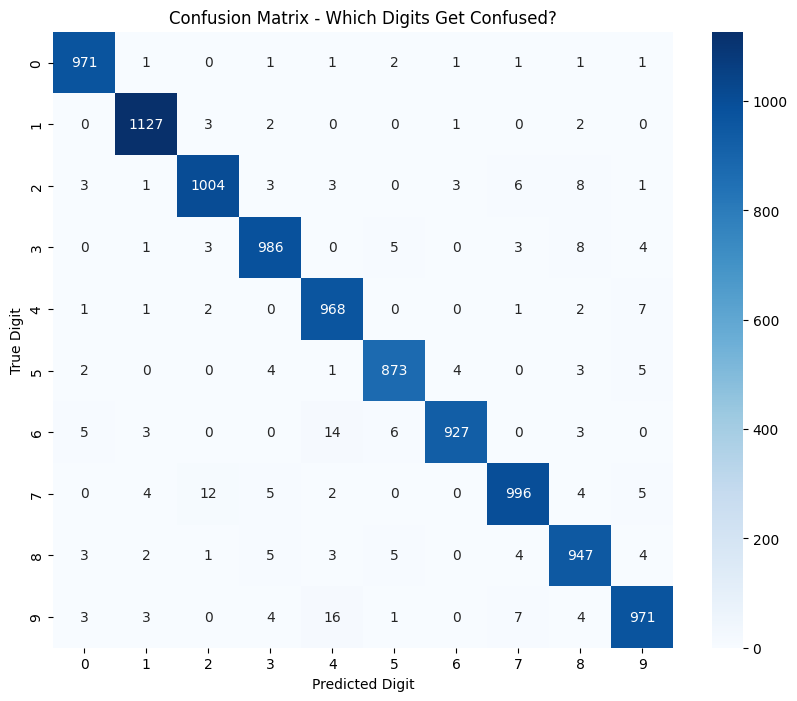

In [ ]:
from sklearn.metrics import confusion_matrix   # Import confusion matrix function
import seaborn as sns                          # Import for colored heatmap

cm = confusion_matrix(y_test, y_pred)          # Creates table: rows=True digits, columns=Predicted digits
plt.figure(figsize=(10,8))                     # Makes figure size 10x8 inches
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Draws colored table, annot=True shows numbers
plt.title('Confusion Matrix - Which Digits Get Confused?')  # Title
plt.xlabel('Predicted Digit')                  # X-axis label
plt.ylabel('True Digit')                       # Y-axis label
plt.show()                                     # Displays the matrix


# plt.ylabel('True Digit')    # "True" means ACTUAL digit (what the image really is)
# cm = confusion_matrix(y_test, y_pred)

# cm	-----Variable name storing confusion matrix (can be any name)
# y_test -----	True labels (actual digits)
# y_pred	------Predicted labels (model's guesses)

# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# cm	----------The confusion matrix data to plot
# annot=True	---------Show numbers inside boxes (True=show, False=hide)
# fmt='d'	---------Format numbers as integers (d = decimal/integer)
# cmap='Blues'	------Color scheme (Blue gradient: light blue to dark blue)


# cmap='Reds'     # Red color scheme
# cmap='Greens'   # Green color scheme
# cmap='Purples'  # Purple color scheme
# cmap='Oranges'  # Orange color scheme


Per-Class Accuracy

In [ ]:
print("\n Accuracy for each digit:")
for digit in range(10):                        # Loop digits 0 to 9
    mask = (y_test == digit)                   # Creates TRUE/FALSE list where digit matches, Find all images of this digit
    correct = (y_test[mask] == y_pred[mask]).sum()  # Counts correct predictions for this digit
    total = mask.sum()                         # Total images of this digit
    acc = correct / total * 100                # Calculate percentage
    print(f"  Digit {digit}: {acc:.2f}%")       # Prints digit number and its accuracy with 2 decimal places

    # Prints heading, \n = new line


 Accuracy for each digit:
  Digit 0: 99.08%
  Digit 1: 99.30%
  Digit 2: 97.29%
  Digit 3: 97.62%
  Digit 4: 98.57%
  Digit 5: 97.87%
  Digit 6: 96.76%
  Digit 7: 96.89%
  Digit 8: 97.23%
  Digit 9: 96.23%


Classification Report

In [ ]:
from sklearn.metrics import classification_report  # Import report function
print("\n Classification Report:")
print(classification_report(y_test, y_pred))   # Shows Precision, Recall, F1-score for each digit


 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.96      0.99      0.97       982
           5       0.98      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



TRAINING/VALIDATION/TESTING PERCENTAGES EXPLANATION

In [ ]:
print("\n ========== UNDERSTANDING PERCENTAGES ==========")
print(f"Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")        # Last epoch training accuracy
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")  # Last epoch validation accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")             # Final test accuracy

print("\n WHAT THESE MEAN:")
print(" Training Accuracy = Model learned from 48,000 images (80% of training data)")
print(" Validation Accuracy = Model tested on 12,000 images (20% of training data) during training")
print(" Test Accuracy = Model tested on 10,000 NEW images (never seen before)")


 ========== UNDERSTANDING PERCENTAGES ==========
Training Accuracy: 99.79%
Validation Accuracy: 97.58%
Test Accuracy: 97.70%

 WHAT THESE MEAN:
 Training Accuracy = Model learned from 48,000 images (80% of training data)
 Validation Accuracy = Model tested on 12,000 images (20% of training data) during training
 Test Accuracy = Model tested on 10,000 NEW images (never seen before)


WRONG PREDICTIONS COUNT

In [ ]:
wrong_count = (y_test != y_pred).sum()         # Count how many predictions are wrong
print(f"\n Wrong predictions: {wrong_count} out of 10000 ({wrong_count/10000*100:.2f}%)")


 Wrong predictions: 230 out of 10000 (2.30%)


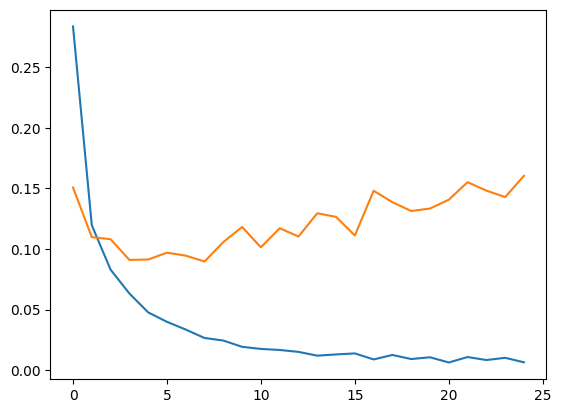

In [ ]:
plt.plot(history.history['loss'])        # Plots training loss (error) decreasing over 25 epochs
plt.plot(history.history['val_loss'])    # Plots validation loss (error on unseen data) over 25 epochs

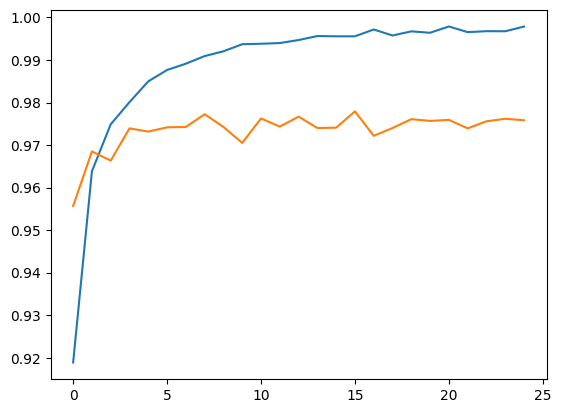

In [ ]:
plt.plot(history.history['accuracy'])        # Plots training accuracy increasing over 25 epochs
#It's about training loss
plt.plot(history.history['val_accuracy'])    # Plots validation accuracy (on unseen data) over 25 epochs

In [ ]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:
X_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

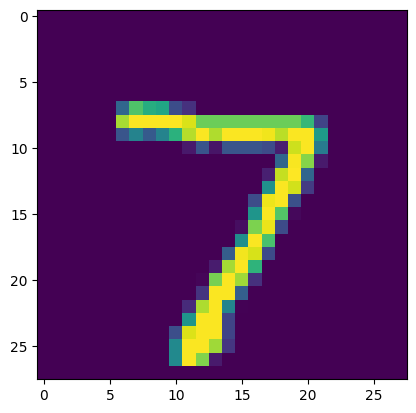

In [ ]:
plt.imshow(X_test[0])   # Displays first test image (28x28 pixels) as picture to see what digit it is

In [ ]:
model.predict(X_test[0].reshape(1,28,28))  # Predicts digit for single image: reshapes (28,28) to (1,28,28) because model expects batch dimension
 #we get probability of every number

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[5.2481232e-24, 3.6818566e-15, 1.7247935e-14, 1.4505360e-11,
        1.1715993e-25, 6.6879338e-26, 4.8922165e-32, 1.0000000e+00,
        1.5936967e-16, 2.1592598e-12]], dtype=float32)

In [ ]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)   # Predicts single image and returns the predicted digit (0-9)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([7])

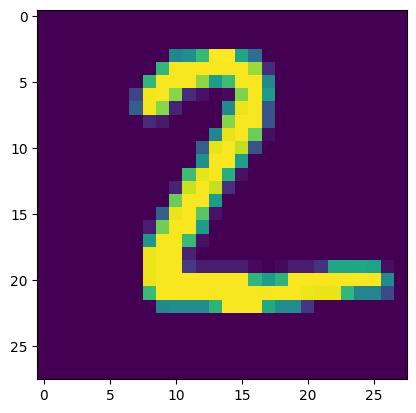

In [ ]:
plt.imshow(X_test[1])   # Displays second test image (28x28 pixels) to see what digit it contains

In [ ]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)   # Predicts digit for second test image and returns the digit (0-9)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([2])